In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

# Importing the objective function history (each row is an average of 4 replicates)
objFunctionHistory_stepwise = []

for idx in range(6):
    objFunctionHistory_stepwise.append([])

for idx in range(2, 6):
    stepNo = idx + 1
    objFunctionHistory_stepwise[idx] = pd.read_csv(f'BSearchresults_GA_step{stepNo}.objectiveFunctionHistory.csv')
    print(f"And now we have step {stepNo}")
    print(objFunctionHistory_stepwise[idx])
    print(" THATS ALL FOLKS ")



And now we have step 3
     search-number  evaluation  number_of_agents*  \
0                1           4               1000   
1                1           8               1000   
2                1          12               1000   
3                1          16               1000   
4                1          20               1000   
..             ...         ...                ...   
140              1         564               1000   
141              1         568               1000   
142              1         572               1000   
143              1         576               1000   
144              1         580               1000   

     number_of_opinion_dimensions* model*  boundary_mean*  set-seed?*  \
0                                1   "HK"            0.03       False   
1                                1   "HK"            0.05       False   
2                                1   "HK"            0.26       False   
3                                1   "HK"       

In [5]:
objFunctionHistory_stepwise

[[],
 [],
 [],
      search-number  evaluation  number_of_agents*  \
 0                1           4               1000   
 1                1           8               1000   
 2                1          12               1000   
 3                1          16               1000   
 4                1          20               1000   
 ..             ...         ...                ...   
 370              1        1484               1000   
 371              1        1488               1000   
 372              1        1492               1000   
 373              1        1496               1000   
 374              1        1500               1000   
 
      number_of_opinion_dimensions* model*  boundary_mean*  set-seed?*  \
 0                                1   "HK"            0.29       False   
 1                                1   "HK"            0.20       False   
 2                                1   "HK"            0.13       False   
 3                                1   "

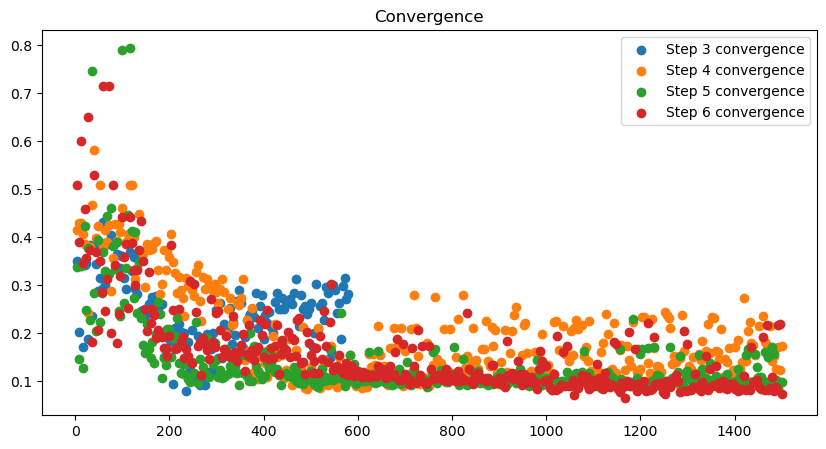

In [18]:
plt.figure(figsize=(10,5))

for idx in range(2, 6):
    stepNo = idx + 1
    x = objFunctionHistory_stepwise[idx]["evaluation"]
    y = objFunctionHistory_stepwise[idx]["fitness"]

    plt.scatter(x,y, label=(f'Step {stepNo} convergence'))
    plt.title('Raw Convergence')
    # plt.
    plt.legend()

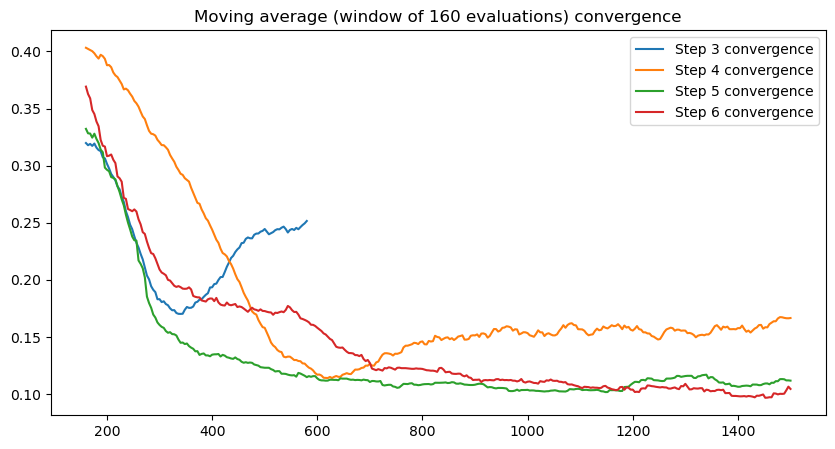

In [36]:
# Moving Averages

window_size = 40

plt.figure(figsize=(10,5))

for idx in range(2, 6):
    stepNo = idx + 1
    x = objFunctionHistory_stepwise[idx]["evaluation"]
    y1 = objFunctionHistory_stepwise[idx]["fitness"]
    y = pd.Series(y1).rolling(window=window_size).mean().to_numpy()

    # print(len(y1))
    # print(len(y))


    plt.plot(x,y, label=(f'Step {stepNo} convergence'))
    plt.title(f'Moving average (window of {window_size*4} evaluations) convergence')
    # plt.
    plt.legend()

In [2]:
# Comparing with the longer trajectory and larger tournament size for step 6
objFunctionHistory_Tsize60 = pd.read_csv(f'BSearchresults_GA_step6_Tsize60_2.5k.objectiveFunctionHistory.csv')


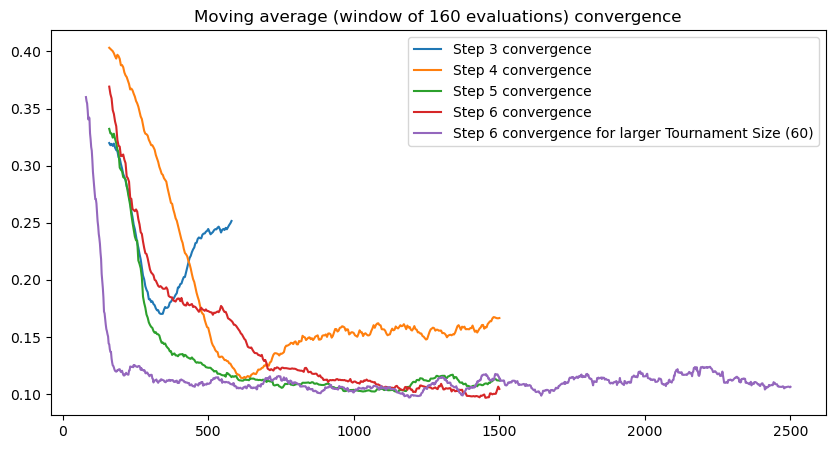

In [5]:
# Moving Averages

window_size = 40

plt.figure(figsize=(10,5))

for idx in range(2, 6):
    stepNo = idx + 1
    x = objFunctionHistory_stepwise[idx]["evaluation"]
    y1 = objFunctionHistory_stepwise[idx]["fitness"]
    y = pd.Series(y1).rolling(window=window_size).mean().to_numpy()

    # print(len(y1))
    # print(len(y))


    plt.plot(x,y, label=(f'Step {stepNo} convergence'))
    plt.title(f'Moving average (window of {window_size*4} evaluations) convergence')
    # plt.

x = objFunctionHistory_Tsize60["evaluation"]
y1 = objFunctionHistory_Tsize60["fitness"]
y = pd.Series(y1).rolling(window=window_size).mean().to_numpy()
plt.plot(x,y, label=(f'Step {stepNo} convergence for larger Tournament Size (60)'))

plt.legend()